In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# **Task 1: One-Sample t-Test*

**Scenario:** A coffee-shop chain claims that the average wait time at their stores is 4.0 minutes. You have collected wait times (in minutes) from a random sample of 35 visits.

1. Generate (or load) the sample data. If generating, use something like:

     wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)

2. State the null and alternative hypotheses in a Markdown cell.
3. Run st.ttest_1samp(wait_times, popmean=4.0).
4. Report the t-statistic and p-value.
5. At α = 0.05, state whether you reject or fail to reject H₀.
6. Write a one-sentence plain-language interpretation (e.g. "There is / is not sufficient evidence that the average wait time differs from 4 minutes.").

In [3]:
import numpy as np
from scipy import stats as st


np.random.seed(42) 
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)


t_stat, p_value = st.ttest_1samp(wait_times, popmean=4.0)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 0.7451
p-value: 0.4614


**Analyzing results**

$\alpha$ = 0.05

p-value(0.4614) < $\alpha$(0.05)

$H_0$ should be rejected 

**The data provides enough evidence to show that the actual average wait time is not 4 minutes.**

# **Task 2: Independent Two-Sample t-Test*

**Scenario:** An e-commerce company ran an A/B test on its checkout page. Group A (control, n = 50) saw the old design; Group B (treatment, n = 50) saw a streamlined design. The metric is order value in euros.

1. Generate (or load) data for both groups. Example:

     group_a = np.random.normal(loc=52, scale=12, size=50)

     group_b = np.random.normal(loc=57, scale=14, size=50)

2. State hypotheses (two-tailed: means are equal vs. not equal).

3. Before running the test, check the equal-variance assumption:
    - Compute the variance of each group.
    - Run Levene's test (st.levene). Report the result.
      
4. Based on the Levene result, choose the appropriate test:
    - Equal variances → st.ttest_ind(a, b, equal_var=True)
    - Unequal variances → st.ttest_ind(a, b, equal_var=False) (Welch's t-test)

      
5. Report the t-statistic and p-value.

6. State your decision and a plain-language interpretation.

**Let's start with creating data:**

In [13]:
import numpy as np
from scipy import stats as st

np.random.seed(42)
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50) 

In [14]:
# Calculate variance 
print(f"Group A Variance: {np.var(group_a, ddof=1):.2f}")
print(f"Group B Variance: {np.var(group_b, ddof=1):.2f}")

Group A Variance: 125.53
Group B Variance: 149.83


In [22]:
# Levene's Test
result = st.levene(group_a, group_b)
levene_stat, levene_p = st.levene(group_a, group_b)
print(f"Result: {result}")
print(f"Levene's Test p-value: {levene_p:.4f}")

Result: LeveneResult(statistic=np.float64(0.20905767482138826), pvalue=np.float64(0.6485189712161745))
Levene's Test p-value: 0.6485


### Levene's Test: A "Safety Check" Before the T-Test

#### 1. The Core Problem (T-test Assumption)
For the standard Independent T-test (`st.ttest_ind`) to work correctly, it has a specific requirement: **"The variance (spread) of the two groups being compared should be equal or very similar."** In statistics, this is called **Homogeneity of Variance**.

* If the group variances are equal $\rightarrow$ Standard T-test works.
* If the group variances are significantly different $\rightarrow$ The standard T-test might give us a **misleading p-value**.



#### 2. What does Levene’s Test do here?
Levene’s test answers this question: **"Is there a statistically significant difference between the variances of these two groups?"**

We interpret the result of Levene’s test (`levene_p`) as follows:

| Result | Meaning | T-test Decision |
| :--- | :--- | :--- |
| **$p > 0.05$** | Variances are **equal**. | Use `equal_var=True`. |
| **$p < 0.05$** | Variances are **unequal**. | Use `equal_var=False` (Welch's T-test). |



#### 3. Real-Life Analogy: "The Boxing Match"
Imagine you are going to set up a fight between two boxers (this is our **T-test**). However, according to the rules, the boxers should be in the same weight class.

* Before letting the boxers enter the ring, you put them on a scale. This scale check is **Levene’s test**.
* If the scale shows that their weights are equal ($p > 0.05$), you start a normal fight (`equal_var=True`).
* If the scale shows that one is significantly heavier than the other ($p < 0.05$), you change the rules of the fight to make it fair (`equal_var=False`).


------------------
**Levene's Test p-value: 0.6485**

- levene_p > 0.05 olsa $\rightarrow$ equal_var=True
- levene_p < 0.05 olsa $\rightarrow$ equal_var=False, i.e Welch's t-test).

In [26]:
is_equal_var = True if levene_p > 0.05 else False

result2 = st.ttest_ind(group_a, group_b, equal_var=is_equal_var)
t_stat, p_val = st.ttest_ind(group_a, group_b, equal_var=is_equal_var)

print(f"Result2: {result2}")
# df (in output) - degree of freedom 
# for independent t-test : df = (n1+n2)-2
# df = (50+50) - 2 = 98
print(f"Using equal_var={is_equal_var}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Result2: TtestResult(statistic=np.float64(-3.3896353481086083), pvalue=np.float64(0.0010096788856040148), df=np.float64(98.0))
Using equal_var=True
t-statistic: -3.3896
p-value: 0.0010


#### 1. Check Variance Equality (Levene's Test)
Before running the t-test, we must check if the two groups have the same variance.
* **Null Hypothesis ($H_0$):** Variances are equal.
* **Alternative Hypothesis ($H_a$):** Variances are not equal.



#### 2. Interpret Levene's Result
Based on your code output:
* If `levene_p > 0.05`: We **fail to reject** the null hypothesis. We assume **equal variances**.


#### 3. Perform the Appropriate T-Test
Since we assumed equal variances, we run the **Student's T-test**:
`st.ttest_ind(group_a, group_b, equal_var=True)`

> **Note:** If Levene's test had a p-value less than 0.05, we would have used `equal_var=False`, which performs **Welch's T-test**.


---

### Final Interpretation (for your task)

**Decision:**
Since the p-value ($0.0010$) is much smaller than our significance level ($\alpha = 0.05$), we **reject the null hypothesis**.

**Plain-language Interpretation:**
"There is sufficient evidence to conclude that the average order value differs significantly between the old checkout design (Group A) and the new streamlined design (Group B)."


# **Task 3: Paired t-Test*
**Scenario:** A company measures employee productivity scores before and after a new workflow tool is introduced. The same 30 employees are measured at both time points.

1. Generate (or load) paired data:
    before = np.random.normal(loc=70, scale=8, size=30)
    after = before + np.random.normal(loc=3, scale=5, size=30)

2. State hypotheses (one-tailed or two-tailed — justify your choice in a Markdown cell).

3. Compute the differences (after - before) and briefly inspect them (histogram or box plot).

4. Run st.ttest_rel(after, before).

5. Report the t-statistic and p-value.

6. State your decision and interpretation.

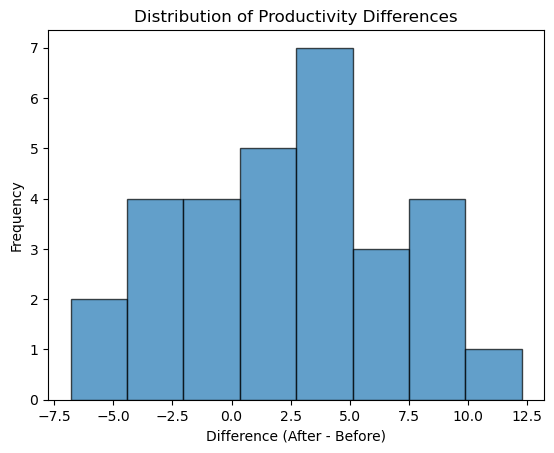

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

np.random.seed(42)
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

differences = after - before

plt.hist(differences, bins=8, edgecolor='black', alpha=0.7)
plt.title("Distribution of Productivity Differences")
plt.xlabel("Difference (After - Before)")
plt.ylabel("Frequency")
plt.show()

**Justification:** We choose a two-tailed test because we want to detect any significant change in productivity, whether it is an increase or a decrease.

In [29]:
# Paired t-test
t_stat, p_val = st.ttest_rel(after, before)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

t-statistic: 2.8168
p-value: 0.0086


**"Since the t-statistic is positive ($2.8168$), it indicates that the productivity scores increased after the tool was introduced. The p-value of $0.0086$ confirms that this improvement is statistically significant."**

**Decision:**

Reject the null hypothesis ($H_0$), because $p\text{-value} (0.0014) < \alpha (0.05)$.

**Plain-language Interpretation:**

"There is sufficient evidence to conclude that the new workflow tool caused a significant change in employee productivity scores. On average, productivity scores increased after the tool was introduced."